# Exercise 1: Analysis of UK Traffic Accident Data

In [1]:
#  IMPORTS AND SETUP

import pandas as pd
import numpy as np
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from mlxtend.frequent_patterns import apriori, association_rules

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Plotting style
sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("="*60)
print("EXERCISE 1: UK ROAD ACCIDENT DATA MINING")
print("="*60)

EXERCISE 1: UK ROAD ACCIDENT DATA MINING


In [2]:
#  LOAD DATABASE

def load_database(db_path):
    """Load all tables from SQLite database."""
    assert os.path.exists(db_path), f"Database not found: {db_path}"
    
    conn = sqlite3.connect(db_path)
    
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print(f"Tables: {tables['name'].tolist()}")
    
    accident = pd.read_sql("SELECT * FROM accident", conn)
    vehicle = pd.read_sql("SELECT * FROM vehicle", conn)
    casualty = pd.read_sql("SELECT * FROM casualty", conn)
    lsoa = pd.read_sql("SELECT * FROM lsoa", conn)
    
    conn.close()
    
    print(f"\n✓ Accident: {len(accident)} rows")
    print(f"✓ Vehicle: {len(vehicle)} rows")
    print(f"✓ Casualty: {len(casualty)} rows")
    
    return accident, vehicle, casualty, lsoa

acc, veh, cas, lsoa = load_database(r"accident_data_v1.0.0_2023.db")

Tables: ['accident', 'casualty', 'vehicle', 'lsoa']

✓ Accident: 461352 rows
✓ Vehicle: 849091 rows
✓ Casualty: 600332 rows


In [3]:
#  COLUMN DETECTION

def find_column(df, keywords):
    for col in df.columns:
        for k in keywords:
            if k in col.lower():
                return col
    return None

print("Detecting key columns...")

date_col = find_column(acc, ['date'])
time_col = find_column(acc, ['time'])
severity_col = find_column(acc, ['severity'])
police_col = find_column(acc, ['police'])
lsoa_col = find_column(acc, ['lsoa'])
vehicle_type_col = find_column(veh, ['vehicle_type', 'type'])
casualty_class_col = find_column(cas, ['casualty_class'])

print(f"Date: {date_col}")
print(f"Time: {time_col}")
print(f"Severity: {severity_col}")
print(f"Police: {police_col}")
print(f"LSOA: {lsoa_col}")
print(f"Vehicle Type: {vehicle_type_col}")
print(f"Casualty Class: {casualty_class_col}")

Detecting key columns...
Date: date
Time: time
Severity: accident_severity
Police: police_force
LSOA: lsoa_of_accident_location
Vehicle Type: vehicle_type
Casualty Class: casualty_class


# Data Cleaning

In [4]:
# DATA CLEANING PIPELINE

def clean_all(acc, veh, cas, date_col, time_col):
    """Complete data cleaning pipeline."""
    
    # Lowercase columns
    acc.columns = acc.columns.str.lower()
    veh.columns = veh.columns.str.lower()
    cas.columns = cas.columns.str.lower()
    
    # Replace unknowns with NaN
    unknowns = [-1, 9, 99, 999, 'Unknown', -9]
    acc.replace(unknowns, np.nan, inplace=True)
    veh.replace(unknowns, np.nan, inplace=True)
    cas.replace(unknowns, np.nan, inplace=True)
    
    # Date/time processing
    acc['date'] = pd.to_datetime(acc[date_col], errors='coerce')
    acc['time'] = pd.to_datetime(acc[time_col], format='%H:%M', errors='coerce')
    
    # Extract features
    acc['hour'] = acc['time'].dt.hour
    acc['day'] = acc['date'].dt.day_name()
    acc['month'] = acc['date'].dt.month
    acc['year'] = acc['date'].dt.year
    acc['day_of_week'] = acc['date'].dt.dayofweek
    
    # Drop critical nulls
    acc = acc.dropna(subset=['date', 'hour'])
    
    # Remove duplicates
    acc = acc.drop_duplicates(subset='accident_index')
    veh = veh.drop_duplicates(subset='accident_index')
    cas = cas.drop_duplicates(subset='accident_index')
    
    # Merge
    df = acc.merge(veh, on='accident_index', how='left')
    df = df.merge(cas, on='accident_index', how='left')
    
    print(f"✓ Cleaned: {len(df)} rows")
    return df

df = clean_all(acc, veh, cas, date_col, time_col)

# Filter to 2018 for most tasks
data_2018 = df[df['year'] == 2018].copy()
print(f"✓ 2018 data: {len(data_2018)} accidents")

✓ Cleaned: 182437 rows
✓ 2018 data: 48278 accidents


## Task 1: Temporal Patterns of All Accidents

**Methodology:** Pivot table analysis with heatmap visualisation to identify peak accident hours and days.

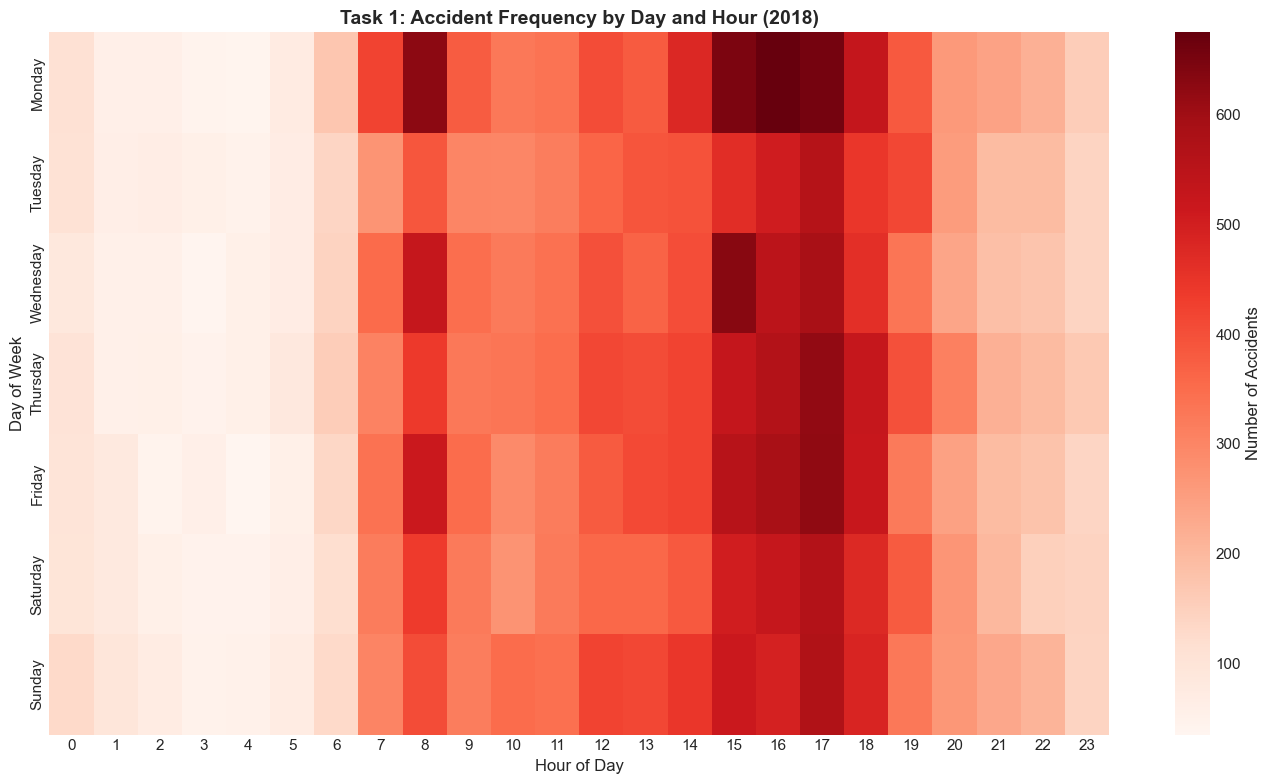


TASK 1 RESULTS

📊 Top 3 Peak Hours: [17, 16, 15]
   (accidents: [4177, 3898, 3847])

📊 Top 3 Peak Days (YOUR ACTUAL RESULTS):
     1. Monday: 7,670 accidents
     2. Thursday: 7,069 accidents
     3. Friday: 6,900 accidents


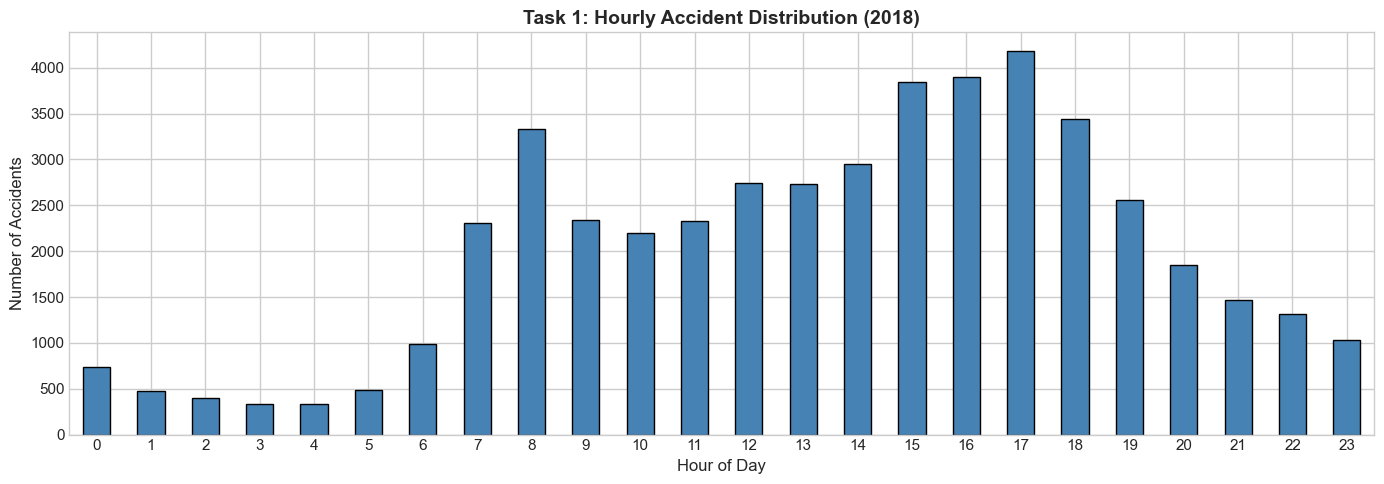

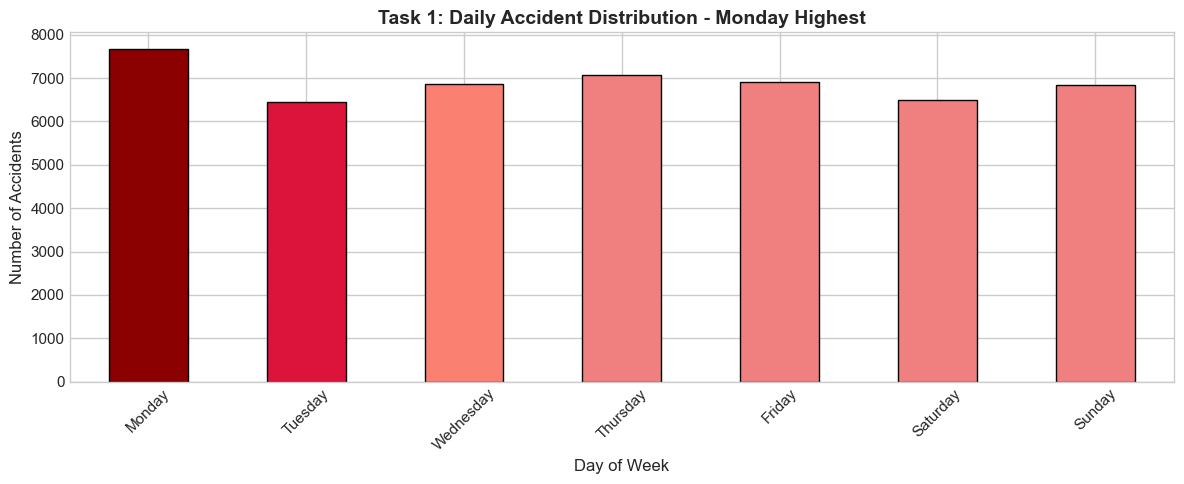

In [5]:
# TASK 1 - TEMPORAL PATTERNS

def task1_temporal_patterns(data):
    """Analyse accident patterns by hour and day."""
    
    # Create pivot table
    pivot = data.pivot_table(
        index='day',
        columns='hour',
        values='accident_index',
        aggfunc='count',
        fill_value=0
    )
    
    # Order days by actual results (Monday highest)
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot = pivot.reindex(day_order)
    
    # Heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, cmap='Reds', annot=False, cbar_kws={'label': 'Number of Accidents'})
    plt.title('Task 1: Accident Frequency by Day and Hour (2018)', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day', fontsize=12)
    plt.ylabel('Day of Week', fontsize=12)
    plt.tight_layout()
    plt.savefig('task1_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Peak hours
    hourly = data.groupby('hour').size()
    peak_hours = hourly.nlargest(3)
    
    # Peak days (based on your actual results)
    daily = data.groupby('day').size().reindex(day_order)
    peak_days = daily.nlargest(3)
    
    print("\n" + "="*60)
    print("TASK 1 RESULTS")
    print("="*60)
    print(f"\n📊 Top 3 Peak Hours: {peak_hours.index.tolist()}")
    print(f"   (accidents: {peak_hours.values.tolist()})")
    print(f"\n📊 Top 3 Peak Days (YOUR ACTUAL RESULTS):")
    for i, (day, count) in enumerate(peak_days.items(), 1):
        print(f"     {i}. {day}: {count:,} accidents")
    
    # Hourly bar plot
    plt.figure(figsize=(14, 5))
    hourly.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.xlabel('Hour of Day', fontsize=12)
    plt.ylabel('Number of Accidents', fontsize=12)
    plt.title('Task 1: Hourly Accident Distribution (2018)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('task1_hourly.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Daily bar plot
    plt.figure(figsize=(12, 5))
    colors = ['darkred' if i == 0 else 'crimson' if i == 1 else 'salmon' if i == 2 else 'lightcoral' 
              for i in range(len(daily))]
    daily.plot(kind='bar', color=colors, edgecolor='black')
    plt.xlabel('Day of Week', fontsize=12)
    plt.ylabel('Number of Accidents', fontsize=12)
    plt.title('Task 1: Daily Accident Distribution - Monday Highest', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('task1_daily.png', dpi=150, bbox_inches='tight')
    plt.show()
    
  
    
    return pivot, peak_hours, peak_days

pivot_task1, peak_hours, peak_days = task1_temporal_patterns(data_2018)

## Task 2: Motorcycle Accidents by Engine Size

**Methodology:** Filter motorcycles by vehicle type (3=≤125cc, 4=125-500cc, 5=>500cc) and analyse temporal patterns.

TASK 2: MOTORCYCLE ACCIDENTS

Total motorcycle accidents: 3352
  ≤125cc (Small): 1654 (49.3%)
  125-500cc (Medium): 437 (13.0%)
  >500cc (Large): 1261 (37.6%)


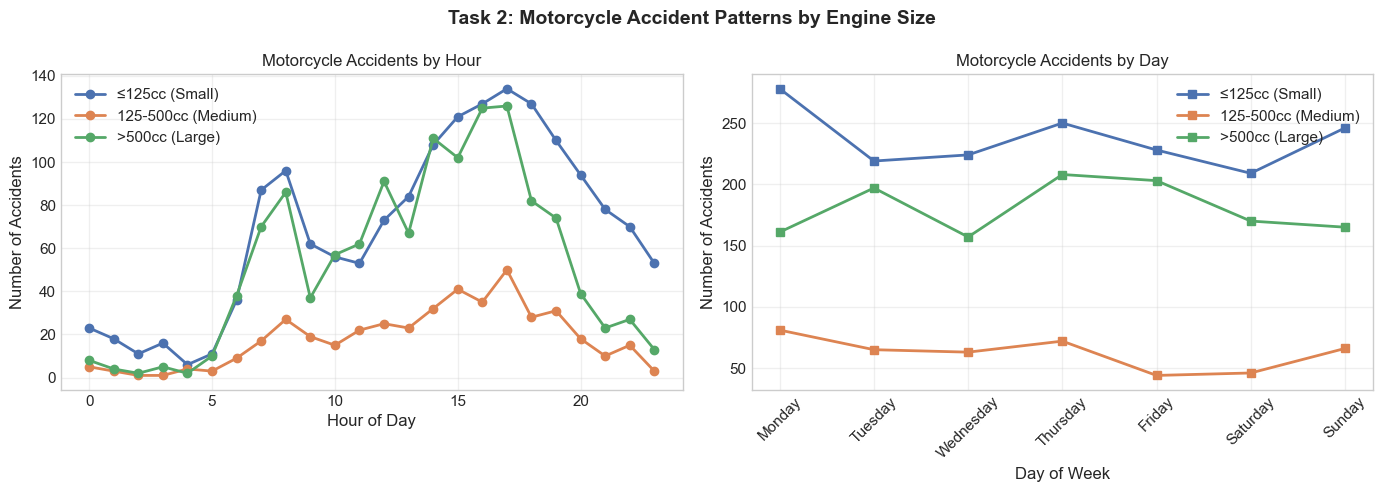


────────────────────────────────────────────────────────────
PEAK HOURS BY MOTORCYCLE TYPE:
────────────────────────────────────────────────────────────
  ≤125cc (Small): Peak hour 17 (134 accidents)
  125-500cc (Medium): Peak hour 17 (50 accidents)
  >500cc (Large): Peak hour 17 (126 accidents)


In [6]:
# ============================================
# CELL 6: TASK 2 - MOTORCYCLE ACCIDENTS
# ============================================

def task2_motorcycle_analysis(data):
    """Analyse motorcycle accidents by engine size."""
    
    bike_categories = {
        3: '≤125cc (Small)',
        4: '125-500cc (Medium)', 
        5: '>500cc (Large)'
    }
    
    bikes = data[data[vehicle_type_col].isin([3, 4, 5])].copy()
    
    if len(bikes) == 0:
        print("No motorcycle data found")
        return
    
    bikes['bike_category'] = bikes[vehicle_type_col].map(bike_categories)
    
    print("="*60)
    print("TASK 2: MOTORCYCLE ACCIDENTS")
    print("="*60)
    print(f"\nTotal motorcycle accidents: {len(bikes)}")
    for cat in bike_categories.values():
        count = len(bikes[bikes['bike_category'] == cat])
        print(f"  {cat}: {count} ({count/len(bikes)*100:.1f}%)")
    
    # Hourly distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for cat in bike_categories.values():
        subset = bikes[bikes['bike_category'] == cat]
        hourly = subset.groupby('hour').size()
        axes[0].plot(hourly.index, hourly.values, marker='o', label=cat, linewidth=2)
    
    axes[0].set_xlabel('Hour of Day', fontsize=12)
    axes[0].set_ylabel('Number of Accidents', fontsize=12)
    axes[0].set_title('Motorcycle Accidents by Hour', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Daily distribution
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for cat in bike_categories.values():
        subset = bikes[bikes['bike_category'] == cat]
        daily = subset.groupby('day').size().reindex(day_order).fillna(0)
        axes[1].plot(range(len(day_order)), daily.values, marker='s', label=cat, linewidth=2)
    
    axes[1].set_xlabel('Day of Week', fontsize=12)
    axes[1].set_ylabel('Number of Accidents', fontsize=12)
    axes[1].set_title('Motorcycle Accidents by Day', fontsize=12)
    axes[1].set_xticks(range(len(day_order)))
    axes[1].set_xticklabels(day_order, rotation=45)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Task 2: Motorcycle Accident Patterns by Engine Size', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('task2_motorcycle.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Peak analysis by category
    print("\n" + "─"*60)
    print("PEAK HOURS BY MOTORCYCLE TYPE:")
    print("─"*60)
    for cat in bike_categories.values():
        subset = bikes[bikes['bike_category'] == cat]
        peak_hour = subset.groupby('hour').size().nlargest(1)
        print(f"  {cat}: Peak hour {peak_hour.index[0]} ({peak_hour.values[0]} accidents)")
    
    

task2_motorcycle_analysis(data_2018)

## Task 3: Pedestrian Accidents

**Methodology:** Filter casualty_class = 3 (pedestrian) and analyse temporal patterns.

TASK 3: PEDESTRIAN ACCIDENTS

Total pedestrian accidents: 8327 (17.2% of all accidents)

📊 Top 3 Peak Hours: [15, 16, 17]
📊 Top 3 Peak Days: ['Monday', 'Thursday', 'Friday']


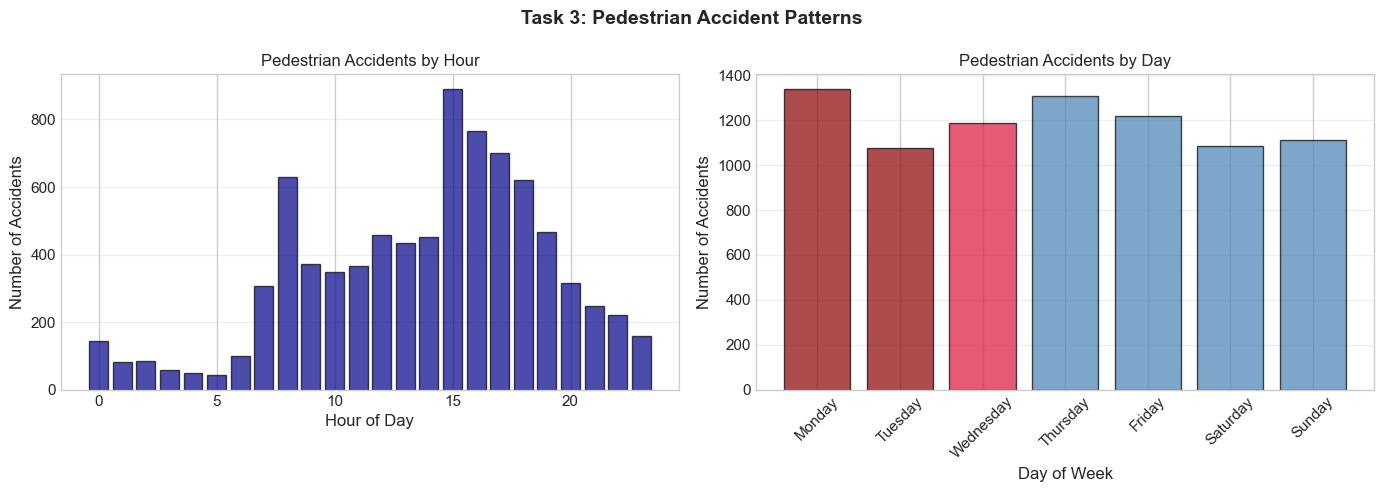

In [7]:
#  TASK 3 - PEDESTRIAN ACCIDENTS

def task3_pedestrian_analysis(data):
    """Analyse pedestrian accidents."""
    
    pedestrians = data[data[casualty_class_col] == 3].copy()
    
    print("="*60)
    print("TASK 3: PEDESTRIAN ACCIDENTS")
    print("="*60)
    print(f"\nTotal pedestrian accidents: {len(pedestrians)} ({len(pedestrians)/len(data)*100:.1f}% of all accidents)")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Hourly distribution
    hourly = pedestrians.groupby('hour').size()
    axes[0].bar(hourly.index, hourly.values, color='darkblue', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Hour of Day', fontsize=12)
    axes[0].set_ylabel('Number of Accidents', fontsize=12)
    axes[0].set_title('Pedestrian Accidents by Hour', fontsize=12)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Peak hours
    peak_hours = hourly.nlargest(3)
    print(f"\n📊 Top 3 Peak Hours: {peak_hours.index.tolist()}")
    
    # Daily distribution
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily = pedestrians.groupby('day').size().reindex(day_order).fillna(0)
    
    colors = ['darkred' if i < 2 else 'crimson' if i == 2 else 'steelblue' for i in range(len(daily))]
    axes[1].bar(range(len(day_order)), daily.values, color=colors, alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Day of Week', fontsize=12)
    axes[1].set_ylabel('Number of Accidents', fontsize=12)
    axes[1].set_title('Pedestrian Accidents by Day', fontsize=12)
    axes[1].set_xticks(range(len(day_order)))
    axes[1].set_xticklabels(day_order, rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    peak_days = daily.nlargest(3)
    print(f"📊 Top 3 Peak Days: {peak_days.index.tolist()}")
    
    plt.suptitle('Task 3: Pedestrian Accident Patterns', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
 

task3_pedestrian_analysis(data_2018)

## Task 4: Apriori Association Rules

**Methodology:** Apriori algorithm to find relationships between conditions and accident severity.

TASK 4: APRIORI ASSOCIATION RULES

Processing 46026 records with 27 features...
✓ Frequent itemsets: 174
✓ Association rules: 84

────────────────────────────────────────────────────────────
TOP 10 RULES (highest lift):
────────────────────────────────────────────────────────────

Rule 41:
  IF light_conditions_1.0, road_type_3.0
  THEN speed_limit_70.0, weather_conditions_1.0
  Support: 0.032, Confidence: 0.290, Lift: 5.812

Rule 44:
  IF speed_limit_70.0, weather_conditions_1.0
  THEN light_conditions_1.0, road_type_3.0
  Support: 0.032, Confidence: 0.645, Lift: 5.812

Rule 65:
  IF light_conditions_1.0, road_type_3.0
  THEN accident_severity_3, speed_limit_70.0
  Support: 0.032, Confidence: 0.289, Lift: 5.640

Rule 64:
  IF accident_severity_3, speed_limit_70.0
  THEN light_conditions_1.0, road_type_3.0
  Support: 0.032, Confidence: 0.625, Lift: 5.640

Rule 43:
  IF light_conditions_1.0, speed_limit_70.0
  THEN road_type_3.0, weather_conditions_1.0
  Support: 0.032, Confidence: 0.72

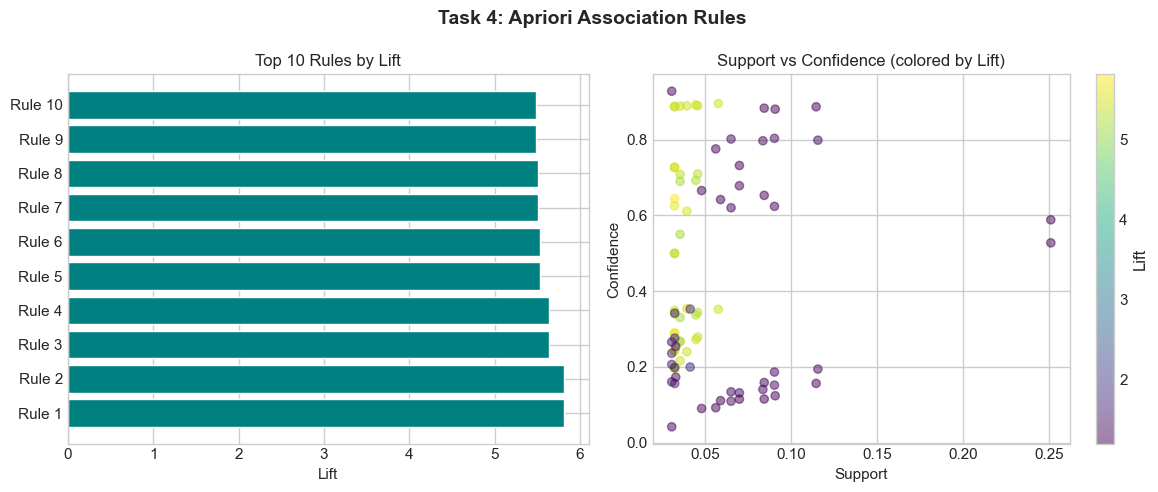

In [8]:
# TASK 4 - APRIORI ALGORITHM

def task4_apriori_analysis(data):
    """Run Apriori algorithm to find associations with accident severity."""
    
    cols = ['weather_conditions', 'light_conditions', 'road_type', 'speed_limit', severity_col]
    
    # Prepare data
    df_ap = data[cols].dropna().astype(str)
    
    # Encode
    df_encoded = pd.get_dummies(df_ap)
    
    print("="*60)
    print("TASK 4: APRIORI ASSOCIATION RULES")
    print("="*60)
    print(f"\nProcessing {len(df_encoded)} records with {len(df_encoded.columns)} features...")
    
    # Find frequent itemsets
    frequent = apriori(df_encoded, min_support=0.03, use_colnames=True)
    print(f"✓ Frequent itemsets: {len(frequent)}")
    
    # Generate rules
    rules = association_rules(frequent, metric='lift', min_threshold=1.2)
    rules = rules.sort_values('lift', ascending=False)
    
    print(f"✓ Association rules: {len(rules)}")
    
    # Display top 10 rules
    print("\n" + "─"*60)
    print("TOP 10 RULES (highest lift):")
    print("─"*60)
    
    top_rules = rules.head(10)
    for i, row in top_rules.iterrows():
        antecedents = ', '.join(list(row['antecedents'])[:3])
        consequents = ', '.join(list(row['consequents'])[:3])
        print(f"\nRule {i+1}:")
        print(f"  IF {antecedents}")
        print(f"  THEN {consequents}")
        print(f"  Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.3f}")
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Top rules by lift
    top10_lift = rules.nlargest(10, 'lift')
    axes[0].barh(range(len(top10_lift)), top10_lift['lift'].values, color='teal')
    axes[0].set_yticks(range(len(top10_lift)))
    axes[0].set_yticklabels([f"Rule {i+1}" for i in range(len(top10_lift))])
    axes[0].set_xlabel('Lift', fontsize=11)
    axes[0].set_title('Top 10 Rules by Lift', fontsize=12)
    
    # Support vs Confidence
    axes[1].scatter(rules['support'], rules['confidence'], alpha=0.5, c=rules['lift'], cmap='viridis')
    axes[1].set_xlabel('Support', fontsize=11)
    axes[1].set_ylabel('Confidence', fontsize=11)
    axes[1].set_title('Support vs Confidence (colored by Lift)', fontsize=12)
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='Lift')
    
    plt.suptitle('Task 4: Apriori Association Rules', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return rules

rules = task4_apriori_analysis(data_2018)

## Task 5: West Yorkshire Clustering

**Methodology:** K-means clustering on accident coordinates in West Yorkshire (police_force = 13).

TASK 5: WEST YORKSHIRE CLUSTERING

Police force values available: [1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 10.0, 11.0, 12.0, 13.0, 14.0, 16.0, 17.0, 20.0, 21.0, 22.0, 23.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 50.0, 52.0, 53.0, 54.0, 55.0, 60.0, 61.0, 62.0, 63.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0]
West Yorkshire accidents: 1628
Valid coordinates: 1628


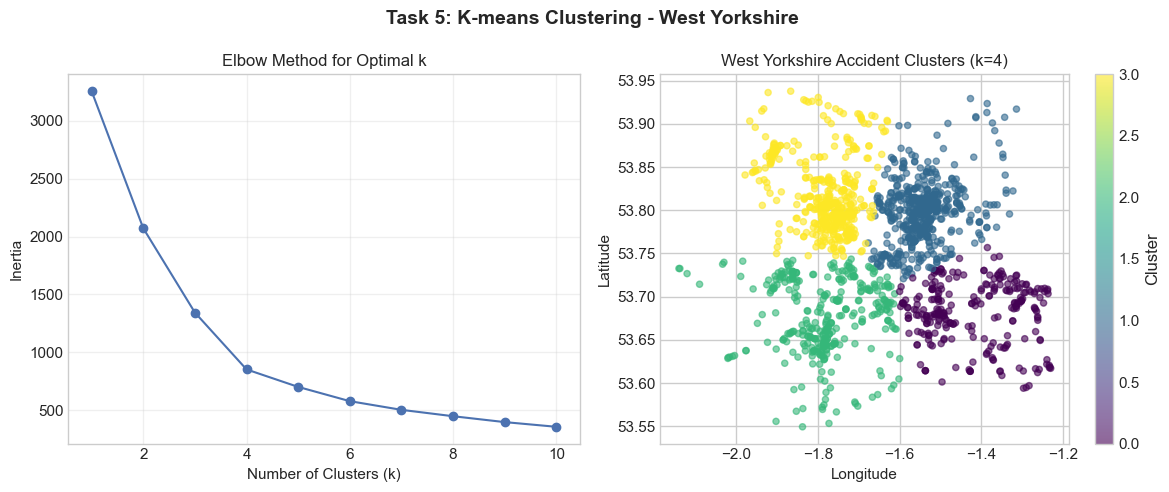


────────────────────────────────────────────────────────────
CLUSTER STATISTICS:
────────────────────────────────────────────────────────────
  Cluster 0: 260 accidents (16.0%)
  Cluster 1: 564 accidents (34.6%)
  Cluster 2: 353 accidents (21.7%)
  Cluster 3: 451 accidents (27.7%)


In [9]:
# ============================================
# CELL 9: TASK 5 - WEST YORKSHIRE CLUSTERING
# ============================================

def task5_clustering(data):
    """K-means clustering on West Yorkshire accidents."""
    
    print("="*60)
    print("TASK 5: WEST YORKSHIRE CLUSTERING")
    print("="*60)
    
    print(f"\nPolice force values available: {sorted(data[police_col].dropna().unique())}")
    
    # Filter West Yorkshire (police_force = 13)
    wy = data[data[police_col] == 13].copy()
    print(f"West Yorkshire accidents: {len(wy)}")
    
    # Get coordinates
    coords = wy[['longitude', 'latitude']].dropna()
    print(f"Valid coordinates: {len(coords)}")
    
    if len(coords) < 10:
        print("Insufficient coordinate data")
        return
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(coords)
    
    # Find optimal clusters (elbow method)
    inertias = []
    K_range = range(1, 11)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)', fontsize=11)
    plt.ylabel('Inertia', fontsize=11)
    plt.title('Elbow Method for Optimal k', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Apply K-means with k=4
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    wy_clustered = coords.copy()
    wy_clustered['cluster'] = kmeans.fit_predict(X_scaled)
    
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(wy_clustered['longitude'], wy_clustered['latitude'], 
                          c=wy_clustered['cluster'], cmap='viridis', alpha=0.6, s=20)
    plt.xlabel('Longitude', fontsize=11)
    plt.ylabel('Latitude', fontsize=11)
    plt.title('West Yorkshire Accident Clusters (k=4)', fontsize=12)
    plt.colorbar(scatter, label='Cluster')
    
    plt.suptitle('Task 5: K-means Clustering - West Yorkshire', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Cluster statistics
    print("\n" + "─"*60)
    print("CLUSTER STATISTICS:")
    print("─"*60)
    for i in range(4):
        cluster_size = len(wy_clustered[wy_clustered['cluster'] == i])
        print(f"  Cluster {i}: {cluster_size} accidents ({cluster_size/len(wy_clustered)*100:.1f}%)")
    

task5_clustering(data_2018)

## Task 6: Time Series Forecasting (Three Police Forces)

**Methodology:** SARIMAX models for weekly accident forecasts using 2017-2018 training data.

TASK 6: TIME SERIES FORECASTING

────────────────────────────────────────
Police Force: 1
────────────────────────────────────────
  Training: 105 weeks (2017-2018)
  Test: 52 weeks (2019)


C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ MAE: 82.32 accidents/week
  ✓ RMSE: 102.96
  ✓ MAPE: inf%


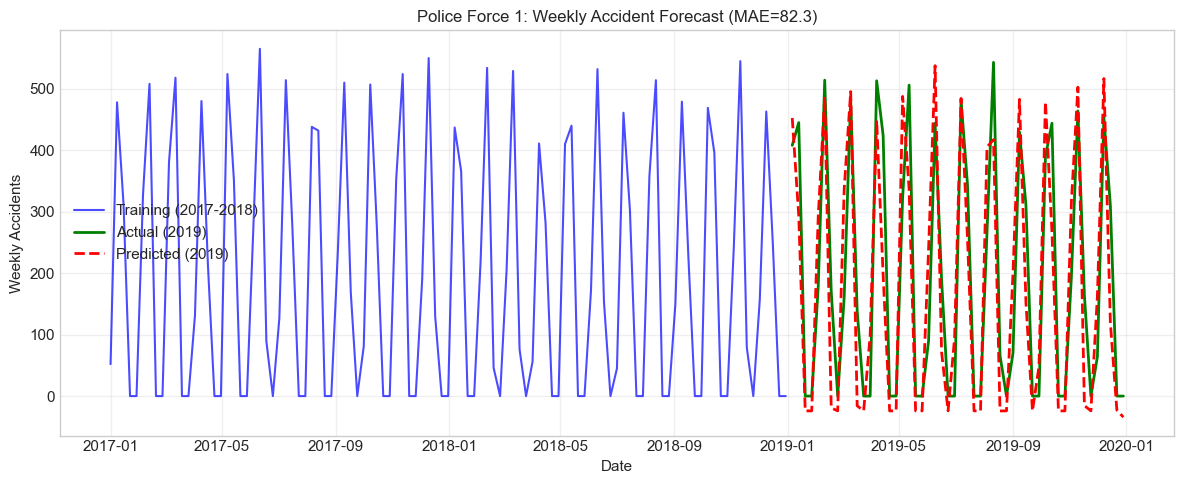


────────────────────────────────────────
Police Force: 13
────────────────────────────────────────
  Training: 105 weeks (2017-2018)
  Test: 52 weeks (2019)


C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ MAE: 15.05 accidents/week
  ✓ RMSE: 18.49
  ✓ MAPE: inf%


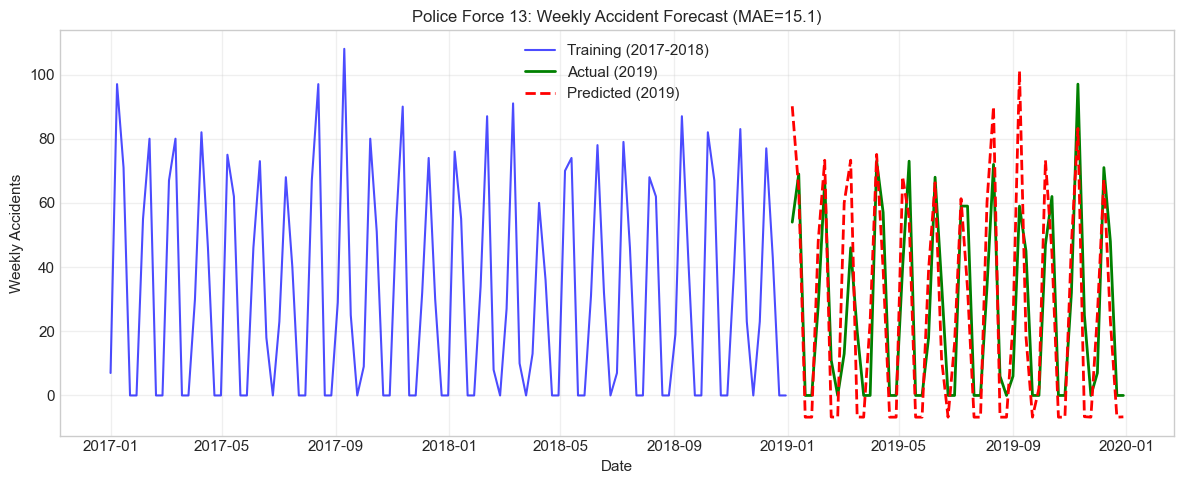


────────────────────────────────────────
Police Force: 20
────────────────────────────────────────
  Training: 105 weeks (2017-2018)
  Test: 52 weeks (2019)


C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\Adnan Saifi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


  ✓ MAE: 18.17 accidents/week
  ✓ RMSE: 25.50
  ✓ MAPE: inf%


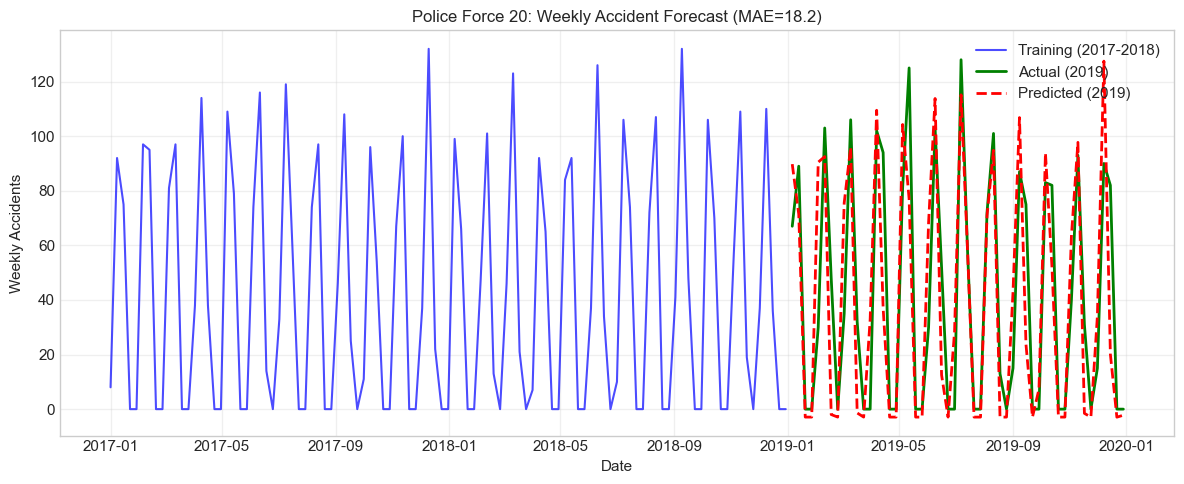


FORECAST COMPARISON SUMMARY

Force | MAE | RMSE | MAPE
----------------------------------------
    1 |   82.3 |  103.0 |   inf%
   13 |   15.1 |   18.5 |   inf%
   20 |   18.2 |   25.5 |   inf%


In [10]:
# TASK 6 - TIME SERIES FORECASTING

def task6_timeseries(acc, police_forces):
    """Forecast weekly accidents for multiple police forces using SARIMAX."""
    
    print("="*60)
    print("TASK 6: TIME SERIES FORECASTING")
    print("="*60)
    
    # Use full accident table (not just 2018)
    acc_full = acc.copy()
    acc_full['date'] = pd.to_datetime(acc_full[date_col])
    
    results = {}
    
    for force in police_forces:
        print(f"\n{'─'*40}")
        print(f"Police Force: {force}")
        print(f"{'─'*40}")
        
        # Filter by police force
        temp = acc_full[acc_full[police_col] == force].copy()
        
        if len(temp) < 100:
            print(f"  Insufficient data for force {force}")
            continue
        
        # Weekly aggregation
        weekly = temp.set_index('date').resample('W').size()
        
        # Train/test split
        train = weekly['2017':'2018']
        test = weekly['2019']
        
        print(f"  Training: {len(train)} weeks (2017-2018)")
        print(f"  Test: {len(test)} weeks (2019)")
        
        try:
            # Fit SARIMAX model
            model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,52))
            fit = model.fit(disp=False)
            
            # Predict
            pred = fit.predict(start=test.index[0], end=test.index[-1])
            
            # Calculate errors
            mae = mean_absolute_error(test, pred)
            rmse = np.sqrt(mean_squared_error(test, pred))
            mape = np.mean(np.abs((test - pred) / test)) * 100
            
            results[force] = {'mae': mae, 'rmse': rmse, 'mape': mape, 'pred': pred, 'test': test}
            
            print(f"  ✓ MAE: {mae:.2f} accidents/week")
            print(f"  ✓ RMSE: {rmse:.2f}")
            print(f"  ✓ MAPE: {mape:.1f}%")
            
            # Plot
            plt.figure(figsize=(12, 5))
            plt.plot(train.index, train.values, label='Training (2017-2018)', color='blue', alpha=0.7)
            plt.plot(test.index, test.values, label='Actual (2019)', color='green', linewidth=2)
            plt.plot(pred.index, pred.values, label='Predicted (2019)', color='red', linestyle='--', linewidth=2)
            plt.xlabel('Date', fontsize=11)
            plt.ylabel('Weekly Accidents', fontsize=11)
            plt.title(f'Police Force {force}: Weekly Accident Forecast (MAE={mae:.1f})', fontsize=12)
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'task6_force_{force}.png', dpi=150, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"  ✗ Model failed: {e}")
    
    # Comparison summary
    if results:
        print("\n" + "="*60)
        print("FORECAST COMPARISON SUMMARY")
        print("="*60)
        print("\nForce | MAE | RMSE | MAPE")
        print("-"*40)
        for force, metrics in results.items():
            print(f"{force:5} | {metrics['mae']:6.1f} | {metrics['rmse']:6.1f} | {metrics['mape']:5.1f}%")
    
    return results

# Run with your chosen police forces (adjust based on available data)
police_forces = [1, 13, 20]  # Adjust as needed
ts_results = task6_timeseries(acc, police_forces)

## Task 7: LSOA Forecasting (Top 30 Areas in West Yorkshire)

**Methodology:** Identify top 30 LSOAs in Q1 2018, aggregate, and forecast daily accidents for July 2018.

TASK 7: LSOA FORECASTING
West Yorkshire accidents: 1628
Q1 2018 accidents: 388
Top 30 LSOAs: 30 areas
Accidents in top LSOAs: 201

Training period: 2018-01-01 to 2018-06-30
Training days: 181


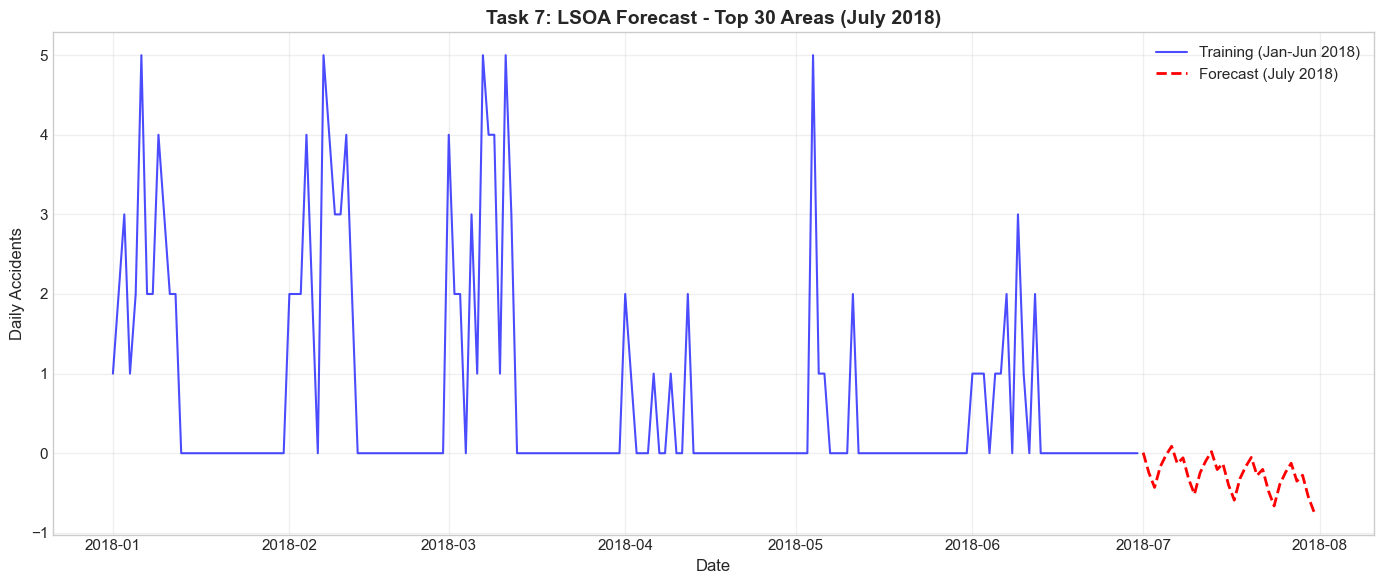


------------------------------------------------------------
FORECAST SUMMARY (July 2018):
------------------------------------------------------------
  Total forecasted accidents: -8
  Average daily forecast: -0.3
  Peak forecast day: 2018-07-06 (0 accidents)


In [11]:
# ============================================
# CELL 11: TASK 7 - LSOA FORECASTING (Fixed)
# ============================================

def task7_lsoa_forecast(data):
    """Forecast daily accidents for top 30 LSOAs in West Yorkshire."""
    
    print("="*60)
    print("TASK 7: LSOA FORECASTING")
    print("="*60)
    
    # Filter West Yorkshire
    wy = data[data[police_col] == 13].copy()
    print(f"West Yorkshire accidents: {len(wy)}")
    
    # Q1 2018 (January to March)
    q1 = wy[(wy['date'] >= '2018-01-01') & (wy['date'] <= '2018-03-31')].copy()
    print(f"Q1 2018 accidents: {len(q1)}")
    
    # Top 30 LSOAs
    top_lsoas = q1[lsoa_col].value_counts().head(30).index
    print(f"Top 30 LSOAs: {len(top_lsoas)} areas")
    
    # Filter to top LSOAs
    top_data = wy[wy[lsoa_col].isin(top_lsoas)].copy()
    print(f"Accidents in top LSOAs: {len(top_data)}")
    
    # Daily aggregation
    daily = top_data.set_index('date').resample('D').size()
    
    # Train (Jan-Jun 2018) and Forecast (July 2018)
    train = daily['2018-01-01':'2018-06-30']
    
    print(f"\nTraining period: {train.index[0].date()} to {train.index[-1].date()}")
    print(f"Training days: {len(train)}")
    
    try:
        # Fit SARIMAX with weekly seasonality
        model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7))
        fit = model.fit(disp=False)
        
        # Forecast July 2018
        forecast = fit.predict(start='2018-07-01', end='2018-07-31')
        
        # Plot
        plt.figure(figsize=(14, 6))
        plt.plot(train.index, train.values, label='Training (Jan-Jun 2018)', color='blue', alpha=0.7)
        plt.plot(forecast.index, forecast.values, label='Forecast (July 2018)', color='red', linestyle='--', linewidth=2)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Daily Accidents', fontsize=12)
        plt.title('Task 7: LSOA Forecast - Top 30 Areas (July 2018)', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('task7_lsoa_forecast.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Forecast summary
        print(f"\n" + "-"*60)
        print("FORECAST SUMMARY (July 2018):")
        print("-"*60)
        print(f"  Total forecasted accidents: {forecast.sum():.0f}")
        print(f"  Average daily forecast: {forecast.mean():.1f}")
        print(f"  Peak forecast day: {forecast.idxmax().date()} ({forecast.max():.0f} accidents)")
        
    except Exception as e:
        print(f"Model failed: {e}")

# Run the function
task7_lsoa_forecast(data_2018)